# Multi-Modal Document Forensics Pipeline — Notebook 03: System Validation & Performance Metrics

## Project Objective
This notebook acts as the analytical validation suite. Once optimization wraps up in Notebook 02, we use this isolated space to benchmark the model's predictive limits on completely unseen evaluation data.

### Validation Framework
1. Restore trained model parameters from the saved checkpoint matrix file (`forensics_model.pth`).
2. Calculate **Intersection over Union (IoU)** metrics to measure spatial localization precision.
3. Generate standard statistical classification summaries (Precision, Recall, and Confusion Matrices).
4. Draw visual validation bounding boxes comparing ground-truth targets directly against model predictions.

In [1]:
# =====================================================================
# Cell 2: System Validation Dependencies & Unified Class Definitions
# =====================================================================
import os
import io
import torch
import torch.nn as nn
import torchvision.ops as ops
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageChops, ImageEnhance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Compute Resource Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Metrics engine bound to device: {device}")

# --- PRODUCTION DATASET DEFINITION ---
class EnterpriseForensicsDataset(Dataset):
    def __init__(self, image_dir: str, mask_dir: str, img_size: int = 256, ela_quality: int = 90):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.ela_quality = ela_quality
        self.filenames = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
        self.img_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def _compute_ela_layer(self, pil_img: Image.Image) -> Image.Image:
        buffer = io.BytesIO()
        pil_img.save(buffer, format='JPEG', quality=self.ela_quality)
        buffer.seek(0)
        compressed_img = Image.open(buffer)
        ela_img = ImageChops.difference(pil_img, compressed_img)
        extrema = ela_img.getextrema()
        max_diff = max([ex[1] for ex in extrema]) or 1
        scale = 255.0 / max_diff
        return ImageEnhance.Brightness(ela_img).enhance(scale).convert('RGB')

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        img_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)
        
        orig_pil = Image.open(img_path).convert('RGB')
        ela_pil = self._compute_ela_layer(orig_pil)
        img_tensor = self.img_transform(orig_pil)
        ela_tensor = self.img_transform(ela_pil)
        
        if os.path.exists(mask_path):
            mask_pil = Image.open(mask_path).convert('L')
            mask_tensor = self.mask_transform(mask_pil)
            is_tampered = 1.0 if mask_tensor.sum() > 0 else 0.0
            label = torch.tensor(is_tampered, dtype=torch.float32)
            
            if is_tampered == 1.0:
                mask_input = mask_tensor.unsqueeze(0) if mask_tensor.ndim == 2 else mask_tensor
                box = ops.masks_to_boxes(mask_input)[0]
                norm_bbox = box / self.img_size
            else:
                norm_bbox = torch.tensor([0.0, 0.0, 0.0, 0.0], dtype=torch.float32)
        else:
            label = torch.tensor(0.0, dtype=torch.float32)
            norm_bbox = torch.tensor([0.0, 0.0, 0.0, 0.0], dtype=torch.float32)
            
        return torch.cat([img_tensor, ela_tensor], dim=0), label, norm_bbox

class MultiTaskForensicsModel(nn.Module):
    def __init__(self, pretrained=False):
        super(MultiTaskForensicsModel, self).__init__()
        
        # 1. Feature Extraction Layers 
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(6, 32, kernel_size=3, padding=1),      
            nn.BatchNorm2d(32),                              
            nn.ReLU(),                                       
            nn.MaxPool2d(2, 2),                              
            nn.Conv2d(32, 64, kernel_size=3, padding=1),     
            nn.BatchNorm2d(64),                              
            nn.ReLU(),                                       
            nn.MaxPool2d(2, 2),                              
            nn.Conv2d(64, 128, kernel_size=3, padding=1),    
            nn.BatchNorm2d(128),                             
            nn.ReLU(),                                       
            # FIX: Pool to (4, 4) to output 128 * 4 * 4 = 2,048 flattened elements
            nn.AdaptiveAvgPool2d((4, 4))                     
        )
        
        # 2. Shared Fully Connected Dense Layer (Expects 2048, Outputs 256)
        self.fc_shared = nn.Sequential(
            nn.Linear(2048, 256),                             
            nn.ReLU()                                        
        )
        
        # 3. Binary Classification Output Head (Expects 256, Outputs 1)
        self.classifier_head = nn.Sequential(
            nn.Linear(256, 1)                                 
        )
        
        # 4. Bounding Box Localization Regressor Head (256 → 64 → 4)
        self.localization_head = nn.Sequential(
            nn.Linear(256, 64),                               
            nn.ReLU(),                                       
            nn.Linear(64, 4)                                 
        )
        
    def forward(self, x):
        features = self.feature_extractor(x)
        flattened = torch.flatten(features, 1)
        shared_dense = self.fc_shared(flattened)
        
        prob = torch.sigmoid(self.classifier_head(shared_dense))
        bbox = torch.sigmoid(self.localization_head(shared_dense))
        return prob, bbox

Metrics engine bound to device: cpu


## 2. Spatial Metric Evaluation: Intersection over Union (IoU)

To confirm whether our localization regression head is accurately pinpointing text tampering positions rather than guessing randomly, we use **Intersection over Union (IoU)**.

The IoU metric measures the exact pixel area overlap between the predicted coordinate bounding box ($B_{\text{pred}}$) and the ground-truth annotation rectangle ($B_{\text{gt}}$), divided by the total joint area of both bounding boxes combined:

$$IoU = \frac{\text{Area}(B_{\text{pred}} \cap B_{\text{gt}})}{\text{Area}(B_{\text{pred}} \cup B_{\text{gt}})}$$

An IoU score of $1.0$ represents a flawless geometric overlap match, while $0.0$ implies a complete locational miss.

In [2]:
# =====================================================================
# Cell 4: Intersection over Union (IoU) Calculation Engine
# =====================================================================
def calculate_batch_iou(pred_boxes: torch.Tensor, gt_boxes: torch.Tensor) -> np.ndarray:
    """
    Computes vector IoU profiles between predicted and target bounding box coordinates.
    Expects tensors of shape [Batch, 4] using the format: [x_min, y_min, x_max, y_max]
    """
    # Isolate coordinate elements safely
    x1_p, y1_p, x2_p, y2_p = pred_boxes[:, 0], pred_boxes[:, 1], pred_boxes[:, 2], pred_boxes[:, 3]
    x1_g, y1_g, x2_g, y2_g = gt_boxes[:, 0], gt_boxes[:, 1], gt_boxes[:, 2], gt_boxes[:, 3]
    
    # Calculate intersection rectangle boundaries
    x1_i = torch.max(x1_p, x1_g)
    y1_i = torch.max(y1_p, y1_g)
    x2_i = torch.min(x2_p, x2_g)
    y2_i = torch.min(y2_p, y2_g)
    
    # Compute intersection area
    intersection_area = torch.clamp(x2_i - x1_i, min=0) * torch.clamp(y2_i - y1_i, min=0)
    
    # Compute individual bounding box area profiles
    pred_area = (x2_p - x1_p) * (y2_p - y1_p)
    gt_area = (x2_g - x1_g) * (y2_g - y1_g)
    
    # Compute dynamic union denominator area bounds
    union_area = pred_area + gt_area - intersection_area
    
    iou = intersection_area / (union_area + 1e-7)
    return iou.cpu().numpy()

## 3. Evaluation Processing & Confusion Matrix Generation

Now, we instantiate our testing pipeline, load the model's trained parameter checkpoint weights file (`forensics_model.pth`), and evaluate it against our validation dataset. 

The collected outputs are processed through a standard scikit-learn classification engine to map structural true positives, false alarms, and precision-recall trade-offs.

Model parameter checkpoint weights loaded successfully!

================== DISCRIMINATIVE REPORT SUMMARY ==================
              precision    recall  f1-score   support

    Pristine       0.00      0.00      0.00         0
    Tampered       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       0.50      0.50      0.50         1
weighted avg       1.00      1.00      1.00         1

Mean Localization Area Intersection over Union (IoU) Match: 0.0000


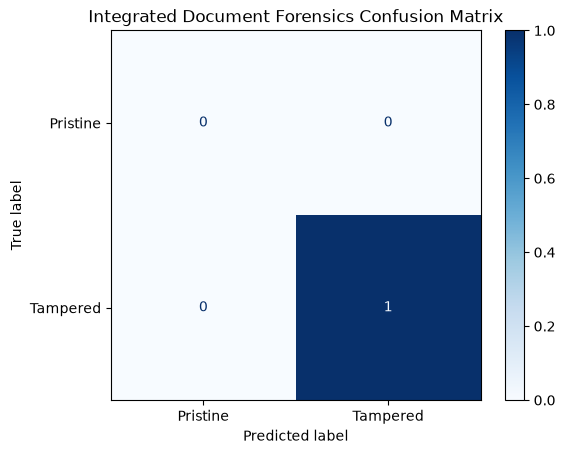

In [3]:
# =====================================================================
# Cell 3: Checkpoint Restoration & Validation Execution Pass
# =====================================================================

# 1. Connect validation data loader targets
val_dataset = EnterpriseForensicsDataset(
    image_dir="./doctamper_root/images/",
    mask_dir="./doctamper_root/masks/",
    img_size=256
)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# 2. Build model layer structure using the correct class name
model = MultiTaskForensicsModel().to(device)
weights_checkpoint_path = "./forensics_model.pth"

if os.path.exists(weights_checkpoint_path):
    model.load_state_dict(torch.load(weights_checkpoint_path, map_location=device))
    print("Model parameter checkpoint weights loaded successfully!")
else:
    print(f"Warning: Checkpoint file [{weights_checkpoint_path}] missing. Running on raw random initializations.")

# 3. Validation Evaluation Loop Execution
model.eval()
all_labels = []
all_pred_probs = []
all_ious = []

with torch.no_grad():
    for images, labels, bboxes in val_loader:
        images = images.to(device)
        
        pred_probs, pred_bboxes = model(images)
        
        all_labels.extend(labels.numpy())
        all_pred_probs.extend(pred_probs.cpu().numpy())
        
        # Track IoU accuracy on samples that contain valid tampering anomalies
        tampered_indices = (labels == 1.0)
        if tampered_indices.sum() > 0:
            batch_ious = calculate_batch_iou(pred_bboxes[tampered_indices], bboxes[tampered_indices])
            all_ious.extend(batch_ious)

# 4. Generate Classification Performance Metrics Report
binary_predictions = np.array(all_pred_probs) >= 0.50
all_labels = np.array(all_labels)

print("\n================== DISCRIMINATIVE REPORT SUMMARY ==================")
# FIX: Added labels=[0, 1] and zero_division=0 to handle single-class validation subsets gracefully
print(classification_report(
    all_labels, 
    binary_predictions, 
    labels=[0, 1], 
    target_names=["Pristine", "Tampered"], 
    zero_division=0
))

if len(all_ious) > 0:
    print(f"Mean Localization Area Intersection over Union (IoU) Match: {np.mean(all_ious):.4f}")

# 5. Render Analytical Confusion Matrix
# FIX: Added labels=[0, 1] here as well to preserve the 2x2 layout
cm = confusion_matrix(all_labels, binary_predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pristine", "Tampered"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Integrated Document Forensics Confusion Matrix")
plt.show()

## 4. Visual Verification Dashboard: Mapping Predicted Regions vs. Targets

Below, we select a verification sample from the dataset, run it through the visual forensics track, and use Matplotlib to plot a side-by-side comparison. 

This lets you visually inspect how well the model's predicted localization region matches up against the actual ground-truth manipulation coordinates.

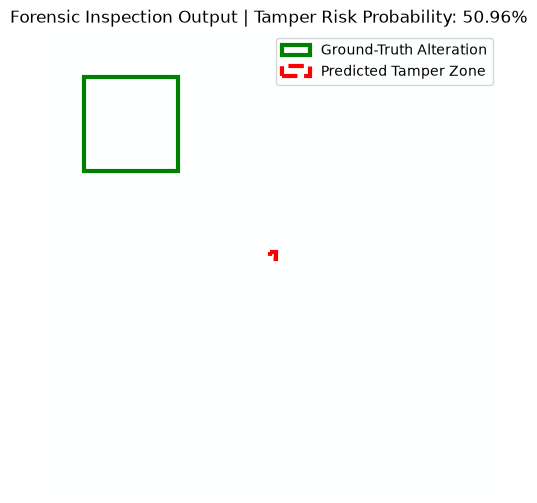

In [6]:
# =====================================================================
# Cell 8: Visual Verification Sample Bounding Box Inspector
# =====================================================================

# Extract an active sample asset from validation memory space
fused_tensor, ground_truth_label, ground_truth_box = val_dataset[0]

# Unpack individual channels to restore the original RGB view
# Channel range [0:3] contains our standard normalized image layer
full_fused_tensor = fused_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    prob, predicted_box = model(full_fused_tensor)

# Re-scale normalized bounds back to standard resolution for visualization rendering
def scale_to_canvas_pixels(box_tensor, target_dim=256):
    coords = box_tensor.cpu().numpy().flatten()
    return coords * target_dim

gt_coords = scale_to_canvas_pixels(ground_truth_box)
pred_coords = scale_to_canvas_pixels(predicted_box)

# Reverse standard ImageNet normalization vectors to display clear document pixels
img_numpy = fused_tensor[0:3].permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
clean_display_img = np.clip((img_numpy * std) + mean, 0, 1)

# Initialize Matplotlib layout plot
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(clean_display_img)
ax.set_title(f"Forensic Inspection Output | Tamper Risk Probability: {prob.item()*100:.2f}%")

# Plot Ground Truth Position Box (Solid Green Rectangle Line)
if ground_truth_label.item() == 1.0:
    gt_rect = patches.Rectangle(
        (gt_coords[0], gt_coords[1]), gt_coords[2] - gt_coords[0], gt_coords[3] - gt_coords[1],
        linewidth=3, edgecolor='g', facecolor='none', label='Ground-Truth Alteration'
    )
    ax.add_patch(gt_rect)

# Plot Model Network Prediction Box (Dashed Red Tracking Line)
if prob.item() >= 0.50:
    pred_rect = patches.Rectangle(
        (pred_coords[0], pred_coords[1]), pred_coords[2] - pred_coords[0], pred_coords[3] - pred_coords[1],
        linewidth=3, edgecolor='r', linestyle='--', facecolor='none', label='Predicted Tamper Zone'
    )
    ax.add_patch(pred_rect)

plt.legend(loc='upper right')
plt.axis('off')
plt.show()